# Template — Ingestão de dados via API RIPE Atlas

**Objetivo:** consumir resultados de uma medição pública da API RIPE Atlas, receber os dados em JSON, transformá-los em um `DataFrame` e salvar a coleta no Google Drive.

> Este notebook cobre **somente a ingestão e o armazenamento da camada `raw`**. Não agregue janelas, não crie variáveis, não rotule dados e não treine modelos nesta etapa.

## Entrega mínima

- Justificar as decisões da equipe sobre os parâmetros da consulta;
- Executar uma requisição válida à API;
- Exibir os dados em um `DataFrame`;
- Salvar o JSON original da resposta;
- Salvar os registros em **CSV ou Parquet** na pasta `raw` do Google Drive;
- Registrar evidências da coleta: URL, parâmetros, horário, quantidade de registros e nomes dos arquivos.


## Pipeline da fase de coleta e ingestão

O desenho abaixo apresenta o percurso desta etapa, desde a escolha da medição pública até a verificação dos arquivos salvos na pasta `raw`. Se a consulta não for válida, a equipe deverá revisar os parâmetros e realizar uma nova tentativa.


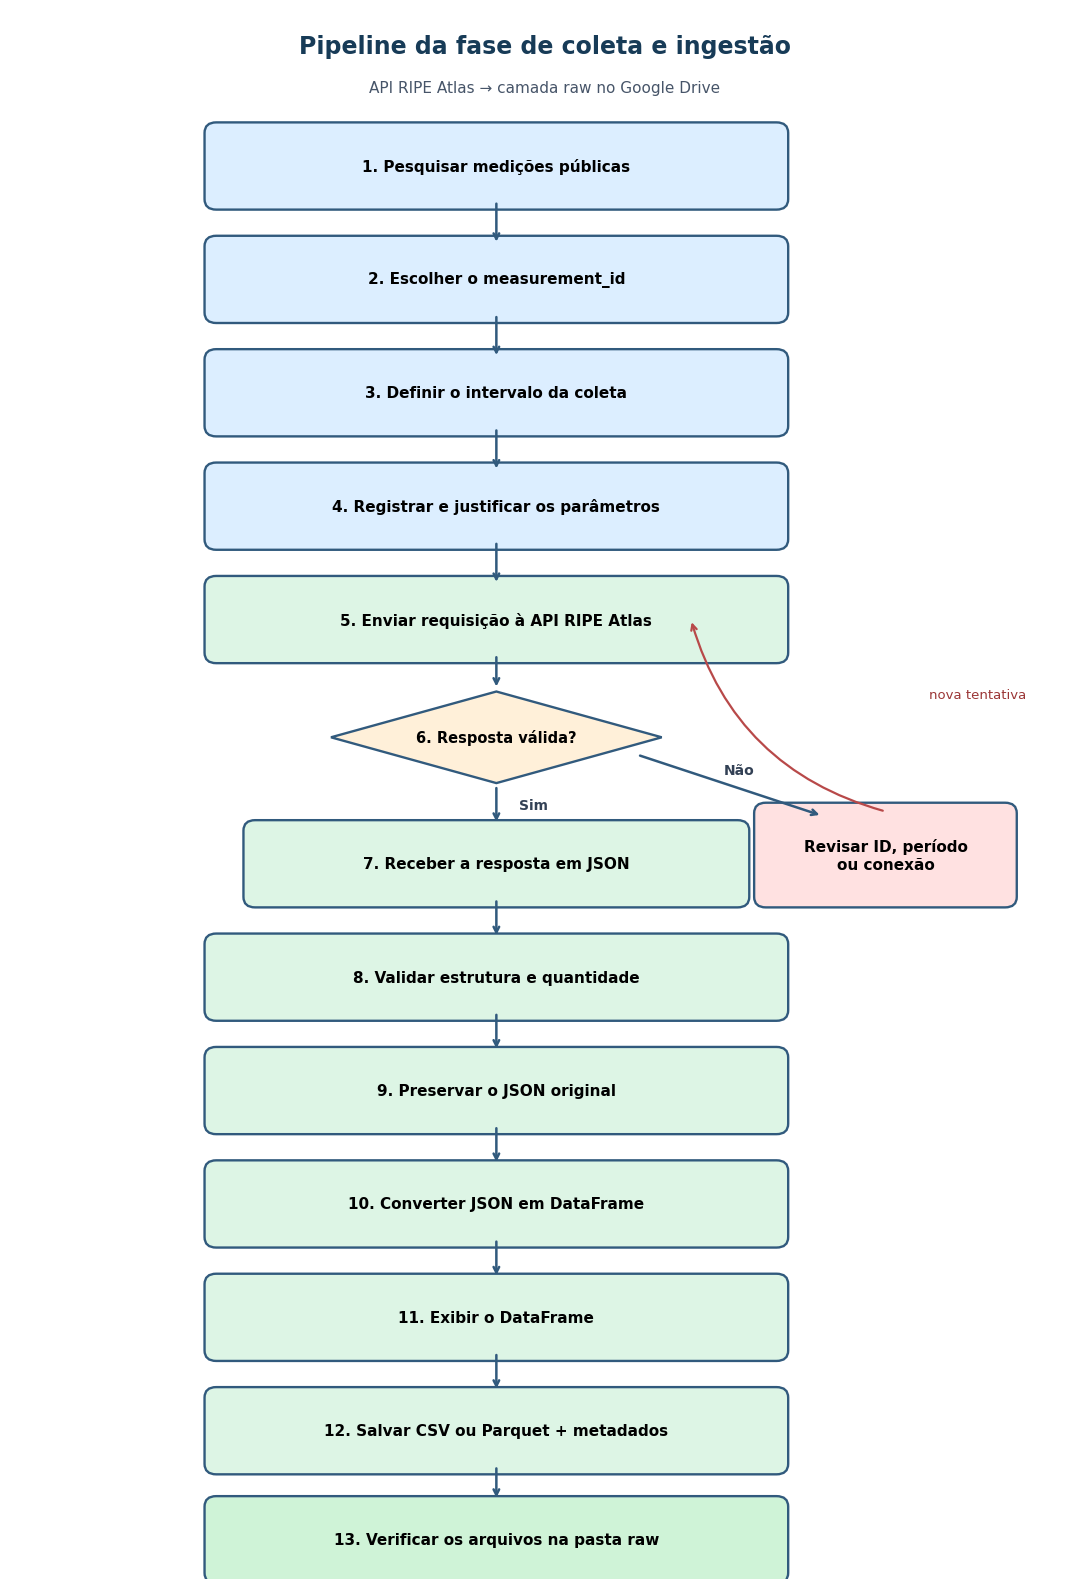

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Polygon

# Desenho do pipeline da fase de coleta e ingestão
fig, ax = plt.subplots(figsize=(11, 16))
ax.set_xlim(0, 11)
ax.set_ylim(0, 18)
ax.axis("off")

azul = "#DCEEFF"
verde = "#DDF5E5"
laranja = "#FFF0D9"
vermelho = "#FFE1E1"
borda = "#315A7D"

def caixa(x, y, texto, cor=azul, largura=5.8, altura=0.8):
    forma = FancyBboxPatch(
        (x - largura / 2, y - altura / 2), largura, altura,
        boxstyle="round,pad=0.10,rounding_size=0.12",
        linewidth=1.7, edgecolor=borda, facecolor=cor
    )
    ax.add_patch(forma)
    ax.text(x, y, texto, ha="center", va="center", fontsize=11, weight="bold")

def decisao(x, y, texto):
    largura, altura = 3.4, 1.05
    pontos = [(x, y + altura/2), (x + largura/2, y),
              (x, y - altura/2), (x - largura/2, y)]
    ax.add_patch(Polygon(pontos, closed=True, edgecolor=borda,
                         facecolor=laranja, linewidth=1.7))
    ax.text(x, y, texto, ha="center", va="center", fontsize=10.5, weight="bold")

def seta(x1, y1, x2, y2, rotulo=None, deslocamento=(0, 0)):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=1.8, color=borda))
    if rotulo:
        ax.text((x1+x2)/2 + deslocamento[0], (y1+y2)/2 + deslocamento[1],
                rotulo, fontsize=10, weight="bold", color="#334155",
                ha="center", va="center")

ax.text(5.5, 17.5, "Pipeline da fase de coleta e ingestão",
        ha="center", fontsize=17, weight="bold", color="#173B57")
ax.text(5.5, 17.05, "API RIPE Atlas → camada raw no Google Drive",
        ha="center", fontsize=11, color="#475569")

etapas = [
    (16.2, "1. Pesquisar medições públicas", azul),
    (14.9, "2. Escolher o measurement_id", azul),
    (13.6, "3. Definir o intervalo da coleta", azul),
    (12.3, "4. Registrar e justificar os parâmetros", azul),
    (11.0, "5. Enviar requisição à API RIPE Atlas", verde),
]
for y, texto, cor in etapas:
    caixa(5, y, texto, cor)

for y1, y2 in [(15.8, 15.3), (14.5, 14.0), (13.2, 12.7), (11.9, 11.4)]:
    seta(5, y1, 5, y2)

decisao(5, 9.65, "6. Resposta válida?")
seta(5, 10.6, 5, 10.2)

# Caminho de erro e nova tentativa
caixa(9.0, 8.3, "Revisar ID, período\nou conexão", vermelho, largura=2.5, altura=1.0)
seta(6.45, 9.45, 8.35, 8.75, "Não", (0.10, 0.18))
ax.annotate("", xy=(7.0, 11.0), xytext=(9.0, 8.8),
            arrowprops=dict(arrowstyle="->", lw=1.6, color="#B84949",
                            connectionstyle="arc3,rad=-0.28"))
ax.text(9.45, 10.1, "nova tentativa", fontsize=9.5, color="#9B3636")

# Caminho principal
caixa(5, 8.2, "7. Receber a resposta em JSON", verde, largura=5.0)
seta(5, 9.1, 5, 8.65, "Sim", (0.38, 0))

caixa(5, 6.9, "8. Validar estrutura e quantidade", verde)
caixa(5, 5.6, "9. Preservar o JSON original", verde)
caixa(5, 4.3, "10. Converter JSON em DataFrame", verde)
caixa(5, 3.0, "11. Exibir o DataFrame", verde)
caixa(5, 1.7, "12. Salvar CSV ou Parquet + metadados", verde)
caixa(5, 0.45, "13. Verificar os arquivos na pasta raw", "#CFF3D7")

for y1, y2 in [(7.8, 7.35), (6.5, 6.05), (5.2, 4.75),
               (3.9, 3.45), (2.6, 2.15), (1.3, 0.9)]:
    seta(5, y1, 5, y2)

plt.tight_layout()
plt.show()


## 1. Identificação da equipe

Preencham antes de executar.

- **Equipe: Grupo 18**
- **Integrantes: Bruno Alves Ribeiro de Souza, Igor da Silva Alves Correa, Pedro Henrique Alexandre da Silva, Samuel de Oliveira Santos, Victoria Agatha Rodrigues Fagundes, Wendel Henrique da Silva Rocha**
- **Turma: Noturno (Quinta)**
- **Data da coleta: 14/09/2026**


## 2. Decisões da equipe

| Decisão | Escolha da equipe | Justificativa |
|---|---|---|
| ID da medição (`measurement_id`) | 1009 | É um measurement da família/tipo periodic Ping IPv4, Volume alto de probes, gratuito e diversos campos para treinamento do modelo |
| Intervalo consultado | Ultimas 0.45 horas | Permite coletar dados recentes e evitar baixar um alto volume de registros |
| Duração do intervalo | 27 minutos | Periodo suficiente para obter uma boa amostra e evitar o processamento desnecessário na máquina |
| Tipo de medição | Ping ICMP | Fornece os valores de RTT, possibilitando o calculo de Jitter, além do sent e rcvd, usados para calcular o packet loss |
| Formato de saída: CSV ou Parquet | CSV | Visualização e configuração simples por meio do pandas |


## 3. Bibliotecas

In [5]:
import json
import time
from datetime import datetime, timedelta, timezone
from pathlib import Path

import pandas as pd
import requests

print("Bibliotecas carregadas.")


Bibliotecas carregadas.


## 4. Montar o Google Drive e preparar a pasta `raw`

O caminho sugerido cria a pasta `ripe_atlas/raw` dentro de `Meu Drive`. A equipe pode alterar somente a pasta do projeto, mantendo uma subpasta chamada `raw`.


Para rodar no Colab


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

PASTA_PROJETO = Path("/content/drive/MyDrive/data_ripe_atlas")
PASTA_RAW = PASTA_PROJETO / "raw"
PASTA_RAW.mkdir(parents=True, exist_ok=True)

print("Arquivos raw serão salvos em:", PASTA_RAW)


Para rodar local:

In [6]:
PASTA_PROJETO = Path("../data_ripe_atlas")
PASTA_RAW = PASTA_PROJETO / "raw"
PASTA_RAW.mkdir(parents=True, exist_ok=True)

## 5. Definir os parâmetros da consulta

Substituam os valores de exemplo pelas decisões da equipe.

- `MEASUREMENT_ID`: identificador numérico de uma medição pública;
- `HORAS_COLETA`: período anterior ao momento da execução;
- `FORMATO_TABELAR`: use `"csv"` ou `"parquet"`;
- `TIMEOUT_REQUISICAO`: tempo máximo de espera, em segundos.

O período usa timestamps Unix em UTC, formato aceito pela API.


In [ ]:
MEASUREMENT_ID = 1009 # Measurement de Ping periódico, ativo desde 22/09/2011 e irá fazer pings até 15/01/2038, possibilitando uma escolha de períodos diferentes, tanto antigos quanto atuais. É publica e gratuita.
HORAS_COLETA = 0.45 # O suficiente para gerar uma média de 100.000 registros, evitando processamento desnecessário e com uma média de 2 a 5% de falhas de conexão.
FORMATO_TABELAR = "csv"  # Muito mais prático e fácil de trabalhar com o Pandas em csv
TIMEOUT_REQUISICAO = 60 # tempo limite para a requisição HTTP em segundos

fim_utc = datetime.now(timezone.utc)
inicio_utc = fim_utc - timedelta(hours=HORAS_COLETA)

URL = f"https://atlas.ripe.net/api/v2/measurements/{MEASUREMENT_ID}/results/"
PARAMETROS = {
    "start": int(inicio_utc.timestamp()),
    "stop": int(fim_utc.timestamp()),
}

assert isinstance(MEASUREMENT_ID, int) and MEASUREMENT_ID > 0
assert HORAS_COLETA > 0
assert FORMATO_TABELAR in {"csv", "parquet"}

print("URL:", URL)
print("Início (UTC):", inicio_utc.isoformat())
print("Fim (UTC):", fim_utc.isoformat())
print("Parâmetros:", PARAMETROS)


URL: https://atlas.ripe.net/api/v2/measurements/1009/results/
Início (UTC): 2026-09-14T02:33:01.674780+00:00
Fim (UTC): 2026-09-14T03:00:01.674780+00:00
Parâmetros: {'start': 1789353181, 'stop': 1789354801}


## 6. Consumir a API e obter o JSON

`raise_for_status()` interrompe a execução quando a API devolve um erro HTTP. A resposta bem-sucedida é convertida de JSON para objetos Python com `response.json()`.


In [31]:
instante_requisicao_utc = datetime.now(timezone.utc)

try:
    response = requests.get(
        URL,
        params=PARAMETROS,
        timeout=TIMEOUT_REQUISICAO,
    )
    response.raise_for_status()
    dados_json = response.json()
except requests.exceptions.Timeout as erro:
    raise RuntimeError("A API não respondeu dentro do tempo definido.") from erro
except requests.exceptions.HTTPError as erro:
    raise RuntimeError(
        f"Erro HTTP {response.status_code}. Verifique o ID e os parâmetros."
    ) from erro
except requests.exceptions.RequestException as erro:
    raise RuntimeError(f"Falha de comunicação com a API: {erro}") from erro
except ValueError as erro:
    raise RuntimeError("A resposta recebida não contém JSON válido.") from erro

if not isinstance(dados_json, list):
    raise TypeError("Era esperada uma lista JSON de resultados.")
if len(dados_json) == 0:
    raise ValueError("A consulta não retornou registros. Reveja o ID ou o período.")

print("Status HTTP:", response.status_code)
print("Quantidade de registros recebidos:", len(dados_json))
print("Tipo do objeto principal:", type(dados_json).__name__)


Status HTTP: 200
Quantidade de registros recebidos: 89071
Tipo do objeto principal: list


## 7. Inspecionar uma pequena amostra do JSON

Exiba somente o primeiro registro para compreender a estrutura sem poluir o notebook. A resposta completa será preservada em arquivo.


In [32]:
print(json.dumps(dados_json[0], indent=2, ensure_ascii=False)[:5000])


{
  "fw": 5080,
  "mver": "2.6.2",
  "lts": 20,
  "dst_name": "198.41.0.4",
  "af": 4,
  "dst_addr": "198.41.0.4",
  "src_addr": "10.0.1.40",
  "proto": "ICMP",
  "ttl": 58,
  "size": 32,
  "result": [
    {
      "rtt": 9.068515
    },
    {
      "rtt": 8.067233
    },
    {
      "rtt": 8.89551
    }
  ],
  "dup": 0,
  "rcvd": 3,
  "sent": 3,
  "min": 8.067233,
  "max": 9.068515,
  "avg": 8.677086000000001,
  "msm_id": 1009,
  "prb_id": 1000000,
  "timestamp": 1789353235,
  "msm_name": "Ping",
  "from": "45.83.6.19",
  "type": "ping",
  "step": 240,
  "stored_timestamp": 1789353338
}


## 8. Transformar o JSON em `DataFrame`

`pd.json_normalize()` transforma cada objeto da lista JSON em uma linha e expande campos aninhados quando possível. Nesta etapa, não removam nem agreguem registros.


In [33]:
df_raw = pd.json_normalize(dados_json, sep="_")

print("Dimensões do DataFrame (linhas, colunas):", df_raw.shape)
display(df_raw.head())


Dimensões do DataFrame (linhas, colunas): (89071, 25)


,fw,mver,lts,dst_name,af,dst_addr,src_addr,proto,ttl,size,...,max,avg,msm_id,prb_id,timestamp,msm_name,from,type,step,stored_timestamp
0,5080,2.6.2,20,198.41.0.4,4,198.41.0.4,10.0.1.40,ICMP,58.0,32,...,9.068515,8.677086,1009,1000000,1789353235,Ping,45.83.6.19,ping,240,1789353338
1,5000,2.0.0,69,198.41.0.4,4,198.41.0.4,193.0.10.94,ICMP,60.0,20,...,4.495759,4.196561,1009,1000003,1789353229,Ping,193.0.10.94,ping,240,1789353276
2,5080,2.6.2,1902220,198.41.0.4,4,198.41.0.4,192.168.2.200,ICMP,54.0,32,...,56.389899,56.323735,1009,1000023,1789353215,Ping,159.146.31.90,ping,240,1789353358
3,5100,2.6.4,56,198.41.0.4,4,198.41.0.4,85.209.51.37,ICMP,56.0,32,...,17.743276,17.197495,1009,1000030,1789353194,Ping,85.209.51.37,ping,240,1789353317
4,5080,2.6.3,44,198.41.0.4,4,198.41.0.4,192.168.201.2,ICMP,44.0,32,...,98.879286,97.885627,1009,1000033,1789353236,Ping,185.64.223.156,ping,240,1789353247


In [34]:
# Conferência básica das colunas e tipos identificados.
df_raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 89071 entries, 0 to 89070
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   fw                89071 non-null  int64  
 1   mver              86163 non-null  str    
 2   lts               89071 non-null  int64  
 3   dst_name          89071 non-null  str    
 4   af                89071 non-null  int64  
 5   dst_addr          89071 non-null  str    
 6   src_addr          89071 non-null  str    
 7   proto             89071 non-null  str    
 8   ttl               88370 non-null  float64
 9   size              89071 non-null  int64  
 10  result            89071 non-null  object 
 11  dup               89071 non-null  int64  
 12  rcvd              89071 non-null  int64  
 13  sent              89071 non-null  int64  
 14  min               89071 non-null  float64
 15  max               89071 non-null  float64
 16  avg               89071 non-null  float64
 17  msm_

## 9. Salvar os dados na pasta `raw`

Serão gerados:

1. Um arquivo `.json` com a resposta original, sem transformação;
2. Um arquivo `.csv` **ou** `.parquet` com o conteúdo exibido no `DataFrame`;
3. Um arquivo de metadados `.json` contendo as evidências da coleta.

O timestamp no nome evita sobrescrever coletas anteriores.


In [35]:
timestamp_arquivo = instante_requisicao_utc.strftime("%Y%m%dT%H%M%SZ")
nome_base = f"ripe_atlas_m{MEASUREMENT_ID}_{timestamp_arquivo}"

caminho_json = PASTA_RAW / f"{nome_base}.json"
with caminho_json.open("w", encoding="utf-8") as arquivo:
    json.dump(dados_json, arquivo, ensure_ascii=False, indent=2)

if FORMATO_TABELAR == "csv":
    caminho_tabela = PASTA_RAW / f"{nome_base}.csv"
    df_raw.to_csv(caminho_tabela, index=False, encoding="utf-8")
else:
    caminho_tabela = PASTA_RAW / f"{nome_base}.parquet"
    df_raw.to_parquet(caminho_tabela, index=False)

metadados = {
    "measurement_id": MEASUREMENT_ID,
    "url": URL,
    "parametros": PARAMETROS,
    "inicio_utc": inicio_utc.isoformat(),
    "fim_utc": fim_utc.isoformat(),
    "coletado_em_utc": instante_requisicao_utc.isoformat(),
    "status_http": response.status_code,
    "quantidade_registros": len(dados_json),
    "quantidade_colunas_dataframe": len(df_raw.columns),
    "arquivo_json": caminho_json.name,
    "arquivo_tabelar": caminho_tabela.name,
}

caminho_metadados = PASTA_RAW / f"{nome_base}_metadata.json"
with caminho_metadados.open("w", encoding="utf-8") as arquivo:
    json.dump(metadados, arquivo, ensure_ascii=False, indent=2)

print("JSON original:", caminho_json)
print("Arquivo tabular:", caminho_tabela)
print("Metadados:", caminho_metadados)


JSON original: ..\data_ripe_atlas\raw\ripe_atlas_m1009_20260914T030005Z.json
Arquivo tabular: ..\data_ripe_atlas\raw\ripe_atlas_m1009_20260914T030005Z.csv
Metadados: ..\data_ripe_atlas\raw\ripe_atlas_m1009_20260914T030005Z_metadata.json


## 10. Verificar se a entrega foi salva

A célula abaixo verifica a existência dos arquivos e lista a pasta `raw`.


In [1]:
assert caminho_json.exists(), "O arquivo JSON não foi encontrado."
assert caminho_tabela.exists(), "O arquivo CSV/Parquet não foi encontrado."
assert caminho_metadados.exists(), "O arquivo de metadados não foi encontrado."

arquivos_gerados = pd.DataFrame(
    {
        "arquivo": [caminho_json.name, caminho_tabela.name, caminho_metadados.name],
        "tamanho_bytes": [
            caminho_json.stat().st_size,
            caminho_tabela.stat().st_size,
            caminho_metadados.stat().st_size,
        ],
    }
)
display(arquivos_gerados)
print("Coleta concluída e salva na pasta raw.")


NameError: name 'caminho_json' is not defined

## 10.5. Pré vizualizaçao do Dataset

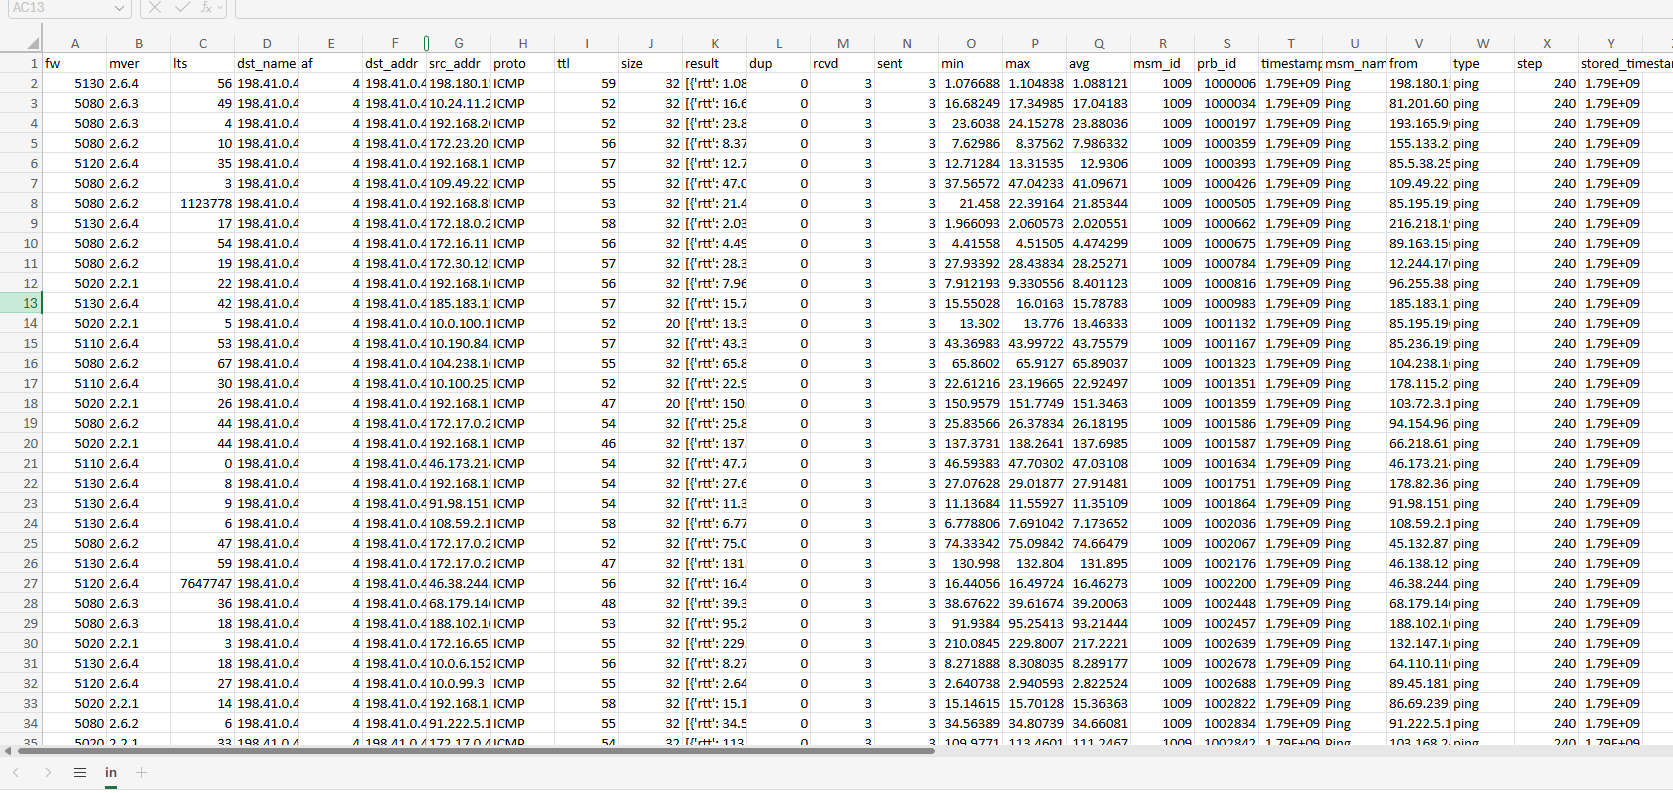

### 11. Contribuições Individuais

Integrante 1 — `Bruno Alves Ribeiro de Souza`

* **Atividade realizada:**
  `Análise do tempo de coletas de dados, chegando a conclusão que 45 minutos retornariam uma média de 90.000 a 100.000 dados, o suficiente para fazer um bom treinamento de máquina e evitar processamento desnecessário - Execução do código e coleta dos dados - criação da célula 10.5 com a pré visualização do Dataset`

* **Parte do trabalho relacionada:**
  `Célula 5, parâmetro HORAS_COLETA.`

* **Tempo dedicado (aproximado):**
  `2h`

* **Evidência da contribuição:**
  `https://hrvoje-smolic.medium.com/how-much-data-do-you-need-for-machine-learning-81daaa0730c1`

* **Explicação da evidência:**
  `Pesquisando um pouco mais sobre qual volumes de dados era ideal para o nosso projeto, encontrei um artigo na Medium.com que reflete qual o volume de dados ideal para o treinamento de um modelo de machine learning, e cheguei a conclusão que para um projeto na qual o nível de complexidade não é tão alto, uma média de 100.000 registros é mais do que o suficiente para fazer um bom treinamento, com uma taxa de 3 a 5% de taxa de falhas de conexões entre esses registros, garantindo uma variedade de dados para que o modelo não aprenda apenas com redes estáveis.`

Integrante 2 — `Wendel Henrique da Silva Rocha`

* **Atividade realizada:**
  `Preenchimento de dados, justificativa de decisões, configuração voltada para ambiente local na criação de pasta, configuração de parametros de requisição e validação da response da API.`

* **Parte do trabalho relacionada:**
  `Sessão 2 e 3 - Inserção de dados da equipe e justificativa de decisões | Sessão 4 - Inclusão de celula para criação de path local | 5 - Alteração de parametros, como destaque measurement_id | 6 e 7 - Analise e validação de dados recebidos. `

* **Tempo dedicado (aproximado):**
  `2h00`

* **Evidência da contribuição:**
  `[Commits](https://github.com/brunoalves2506/Modelo-preditivo---Projeto-Acad-mico---4-Semestre/commits/main/) SHA dos commits: e85af6fecaa8d9e49913c0cac0def5522b326212 | 98b60765225b28cad1beeb13e95cfc12a6ddda43` 

* **Explicação da evidência:**
  `Os commits representam as alterações iniciais feita no arquivo, evidenciando a inserção de novas seções (Na seção 4) e preenchimento dos dados requisitados (2 e 3), alem da alteração de parametros exigidos nas seções posteriores (Na seção 5)`

Integrante 3 — `Victoria Agatha Rodrigues Fagundes`

* **Atividade realizada:**
  `Escreveu e ajustou a Seção 1 (Situação) do memorando de decisão, definindo em uma frase qual decisão precisava ser tomada e por quê, sem antecipar a recomendação. Na coleta de Dados, identificou e corrigiu a falha na Seção 4: o rótulo da célula estava trocado (dizia "Para rodar no Jupyter" mas o código era do Google Colab) e havia um erro (ModuleNotFoundError) salvo no output, que foi limpo após o ajuste.`
* **Parte do trabalho relacionada:**
  `memorando_de_decisao_grupo18.md (Seção 1 - Situação) | coleta_de_dados.ipynb (Seção 4 - montagem do Google Drive/pasta local)`

* **Tempo dedicado (aproximado):**
  `1h30`

* **Evidência da contribuição:**
  `https://github.com/brunoalves2506/Modelo-preditivo---Projeto-Acad-mico---4-Semestre/commit/e1a65943c3d3f2c08e2212d5e1058a73b456a9cb`

* **Explicação da evidência:**
  `O commit mostra a atualização do coleta_de_dados.ipynb com a correção do rótulo e a limpeza do output de erro na Seção 4.`


Integrante 4 — `Samuel de Oliveira Santos`

* **Atividade realizada:**
  `Pesquisas sobre a API do RIPE Atlas Realizei pesquisas na documentação da API utilizada, nas quais todas as informações contribuíram para o desenvolvimento do grupo como um todo. Além disso, realizou uma revisão geral da documentação para avaliar possíveis erros antes da entrega final, também disponibilizou um estudo sobre requisição de dados com a API.`

* **Parte do trabalho relacionada:**
  `Revisão, correção de erros e pesquisa.`

* **Tempo dedicado (aproximado):**
  `2h`

* **Evidência da contribuição:**
  `https://github.com/Samulesantos20045/Evidencias.git`

* **Explicação da evidência:**
  `Comprovam As Atividades realizadas Mensionadas a cima, As reviçoes realizadas os estudos fornecidos e as alteraçoes que foram feitas.`

Integrante 5 — `Pedro Henrique Alexandre da Silva`

* **Atividade realizada:**
  `Atuou como Revisor de Qualidade (QA) e Auditor do projeto. Realizou a validação cruzada entre o código executado e a documentação técnica, garantindo o alinhamento dos parâmetros de coleta (como a janela temporal de 45 minutos e a data oficial) e das métricas extraídas do JSON (como o campo `sent`). Além disso, fui responsável pela formatação estruturada do Registro Final da Equipe (Seção 12) e pela padronização geral do repositório (README e Memorando), aplicando as diretrizes de higienização de documentação e garantindo a segurança e privacidade de dados nas evidências do projeto.`

* **Parte do trabalho relacionada:**
  `Validação técnica do pipeline (Seções 1, 2, 5, 11 e 12 do notebook) e auditoria de qualidade/segurança da documentação externa.`

* **Tempo dedicado (aproximado):**
  `3h15`

* **Evidência da contribuição:**
  `https://github.com/brunoalves2506/Modelo-preditivo---Projeto-Acad-mico---4-Semestre/commit/a7213fafc2e9aaa657063c5bbcd2958fb80d02dd`

* **Explicação da evidência:**
  `O commit comprova a auditoria técnica final, a validação dos parâmetros executados pela equipe e a padronização profissional do artefato entregue para avaliação.`

Integrante 6 — `Igor da Silva Alves Correa`

* **Atividade realizada:**
  `Produziu o registro final da equipe, além de revisar e corrigir poucos erros que estávamos tendo com o notebook`

* **Parte do trabalho relacionada:**
  `Seção 12, Checklist, e registro final`

* **Tempo dedicado (aproximado):**
  `1h30`

* **Evidência da contribuição:**
  `(https://github.com/brunoalves2506/Modelo-preditivo---Projeto-Acad-mico---4-Semestre/commit/main/) SHA dos commits: 0bf1aa2f88120fc2b89eedcd891b299c15874ba3, 4640d6d112bf6c2518d972e23c403ea1e2dca238 `

* **Explicação da evidência:**
  `Esses commits comprovam que o integrante além de ter contribuído, ele também estava ciente do processo que foi o restante do preenchimento do notebook`






**Observação**:

Evidências aceitas
1. histórico de edição de documento compartilhado;
2. commit ou pull request no GitHub;
3. arquivo ou trecho de código produzido;
4. relatório, planilha, diagrama, apresentação ou rascunho;
5. registro de tarefa no Trello, GitHub Projects ou ferramenta semelhante;
6. registro de testes realizados;
7. print de reunião, conversa ou e-mail relacionado à atividade;
8. outro material que demonstre claramente a contribuição individual.

Sendo que a evidência deverá identificar o aluno e estar relacionada à atividade declarada. Sempre que possível, apresente materiais com data, autoria ou histórico de edição. Verifique se todos os links estão acessíveis. Trabalhos realizados em conjunto também devem indicar a contribuição específica de cada integrante. Respostas genéricas, como “ajudei no trabalho”, “fiz a pesquisa” ou “participei do código”, não serão consideradas suficientes. Prints de conversas podem complementar a comprovação, mas não devem ser a única evidência quando houver um produto verificável, como código, documento, planilha ou apresentação.
A ausência de descrição ou de evidência poderá impedir a validação da contribuição individual.

## 12. Checklist da equipe

- [X] Identificamos os integrantes e a turma;
- [X] Justificamos o ID da medição e o intervalo escolhido;
- [X] A requisição terminou com status HTTP 200;
- [X] O JSON retornou pelo menos um registro;
- [X] Exibimos o `DataFrame` no notebook;
- [X] Salvamos o JSON original na pasta `raw`;
- [X] Salvamos o DataFrame em CSV ou Parquet na pasta `raw`;
- [X] Mantivemos o arquivo de metadados da coleta;
- [X] Não realizamos limpeza, agregação, rotulação ou treinamento nesta etapa.

### Registro final da equipe

**Considerações Finais:**
Foram coletados 89.071 registros de ping provenientes da medição pública nº 1009 do RIPE Atlas, ativa desde 2011 e direcionada ao servidor raiz DNS 198.41.0.4. A coleta foi realizada em 14/09/2026, durante aproximadamente 27 minutos, entre 02h33 e 03h00 UTC, com o objetivo de obter uma amostra próxima de 100 mil registros sem gerar um volume excessivo de dados para processamento. 

**Armazenamento na Camada Raw:**
Os dados coletados foram armazenados em três arquivos na pasta `raw`: 
* O arquivo JSON original retornado pela API (~63,6 MB); 
* A versão tabular em formato CSV (~20,6 MB); 
* Um arquivo contendo os metadados da coleta (incluindo URL, parâmetros, horários e quantidade de registros). 

**Conclusão da Etapa:**
Nesta etapa, os dados foram mantidos em seu estado original, sendo realizada apenas a conversão para `DataFrame`, sem aplicação de processos de limpeza, agregação ou outras transformações. Essa abordagem permitiu preservar os dados brutos e garantir maior rastreabilidade. Como resultado, a coleta estabeleceu uma base de dados adequada para as próximas etapas de tratamento, possibilitando a extração das características de latência, perda de pacotes e jitter para o modelo preditivo.